# Классификация Oxford Pets

Обучим сеть для классификации исходного датасета [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Загрузите датасет с Kaggle.

In [1]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar xfz images.tar.gz
!tar xfz annotations.tar.gz
!rm images.tar.gz annotations.tar.gz

--2026-05-11 19:03:39--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-05-11 19:03:40--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  26.8MB/s    in 30s     

2026-05-11 19:04:11 (25.3 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-05-11 19:04:11--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [2]:
!ls annotations
!cat annotations/README

list.txt  README  test.txt  trainval.txt  trimaps  xmls
OXFORD-IIIT PET Dataset
-----------------------
Omkar M Parkhi, Andrea Vedaldi, Andrew Zisserman and C. V. Jawahar

We have created a 37 category pet dataset with roughly 200 images for each class. 
The images have a large variations in scale, pose and lighting. All images have an 
associated ground truth annotation of breed, head ROI, and pixel
level trimap segmentation.

Contents:
--------
trimaps/ 	Trimap annotations for every image in the dataset
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
		Each entry in the file is of following nature:
		Image CLASS-ID SPECIES BREED ID
		ID: 1:37 Class ids
		SPECIES: 1:Cat 2:Dog
		BREED ID: 1-25:Cat 1:12:Dog
		All images with 1st letter as captial are cat images while
		images with small first letter are dog images.
trainval.txt	Files describing splits used in 

###Установка и импорт

In [9]:
!pip install tensorflow-datasets grad-cam==1.4.8 open_clip_torch -q

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, top_k_accuracy_score
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


###Загрузка Oxford Pets (TensorFlow Datasets)

In [10]:
dataset, info = tfds.load('oxford_iiit_pet', split='train', with_info=True, as_supervised=True)

def preprocess_tf_to_pytorch(dataset, img_size=(224,224)):
    images, labels = [], []
    for img, label in tfds.as_numpy(dataset):
        from PIL import Image
        img_pil = Image.fromarray(img).resize(img_size)
        img_tensor = transforms.ToTensor()(img_pil)
        images.append(img_tensor)
        labels.append(label)
    return images, labels

X, y = preprocess_tf_to_pytorch(dataset)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

class OxfordPetsDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Нормализация для предобученных моделей
transform = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
train_ds = OxfordPetsDataset(X_train, y_train, transform=transform)
val_ds = OxfordPetsDataset(X_val, y_val, transform=transform)
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

Train samples: 2944, Val samples: 736


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


###Обучение трёх классификаторов (VGG16, VGG19, ResNet)

In [11]:
models_dict = {
    'VGG16': models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1),
    'VGG19': models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1),
    'ResNet50': models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
}
num_classes = 37
epochs = 5
results = {}

for name, model in models_dict.items():
    print(f"\n{'-'*40}\nОбучение {name}\n{'-'*40}")
    # Заморозка всех слоёв
    for param in model.parameters():
        param.requires_grad = False
    # Замена последнего слоя
    if 'VGG' in name:
        model.classifier[6] = nn.Linear(4096, num_classes)
        optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001)
    else:  # ResNet
        model.fc = nn.Linear(2048, num_classes)
        optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_accs = [], []
    for epoch in range(epochs):
        # Обучение
        model.train()
        total_loss = 0.0
        loop = tqdm(train_loader, desc=f"{name} Epoch {epoch+1}", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        # Валидация
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        acc = correct / total
        val_accs.append(acc)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Val Acc = {acc:.4f}")
    results[name] = {'model': model, 'val_acc': val_accs[-1], 'train_losses': train_losses, 'val_accs': val_accs}

# Сравнение итоговых точностей
print("\nИтоговые точности на валидации:")
for name, res in results.items():
    print(f"{name:10s}: {res['val_acc']:.4f}")
best_model_name = max(results, key=lambda x: results[x]['val_acc'])
best_model = results[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name} с точностью {results[best_model_name]['val_acc']:.4f}")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:10<00:00, 56.9MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]



----------------------------------------
Обучение VGG16
----------------------------------------


...

Epoch 3: Loss = 0.3666, Val Acc = 0.8954


ResNet50 Epoch 4:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 4: Loss = 0.2740, Val Acc = 0.8927


ResNet50 Epoch 5:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 5: Loss = 0.2348, Val Acc = 0.9130

Итоговые точности на валидации:
VGG16     : 0.9090
VGG19     : 0.8899
ResNet50  : 0.9130

Лучшая модель: ResNet50 с точностью 0.9130


###Точность бинарной классификации

In [12]:
# Метка кошки = 0 (породы 1–25), собаки = 1 (26–37)
binary_labels_val = [0 if lbl < 25 else 1 for lbl in y_val]
binary_preds = []
best_model.eval()
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)
        binary_preds.extend([0 if p.item() < 25 else 1 for p in preds])
binary_acc = accuracy_score(binary_labels_val, binary_preds)
print(f"Бинарная точность (кошка/собака) на валидации: {binary_acc:.4f}")

Бинарная точность (кошка/собака) на валидации: 0.9633


###Confusion Matrix

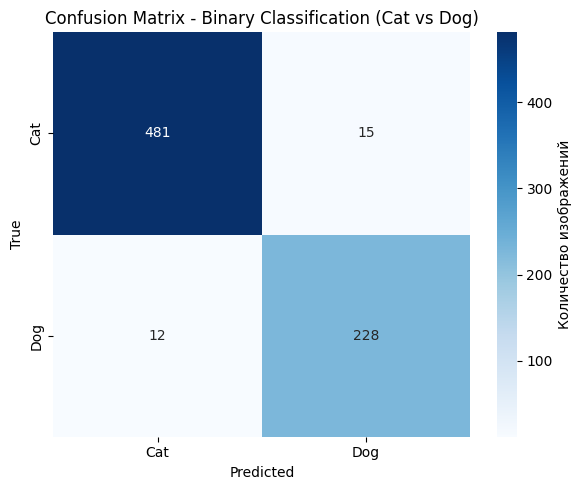


True Cat: 481 correctly, 15 misclassified as Dog
True Dog: 228 correctly, 12 misclassified as Cat


In [15]:
import seaborn as sns

cm = confusion_matrix(binary_labels_val, binary_preds)
labels = ['Cat', 'Dog']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Количество изображений'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Binary Classification (Cat vs Dog)')
plt.tight_layout()
plt.show()

print(f"\nTrue Cat: {cm[0,0]} correctly, {cm[0,1]} misclassified as Dog")
print(f"True Dog: {cm[1,1]} correctly, {cm[1,0]} misclassified as Cat")

###Top-3 и Top-5 Accuracy

In [16]:
y_true = all_labels
y_pred = np.array(all_preds)
best_model.eval()
all_probs = []
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
all_probs = np.array(all_probs)
top3_acc = top_k_accuracy_score(y_true, all_probs, k=3)
top5_acc = top_k_accuracy_score(y_true, all_probs, k=5)
print(f"Top-3 Accuracy: {top3_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Top-3 Accuracy: 0.9823
Top-5 Accuracy: 0.9946


###Grad-CAM – матрица 5×5

Целевой слой: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


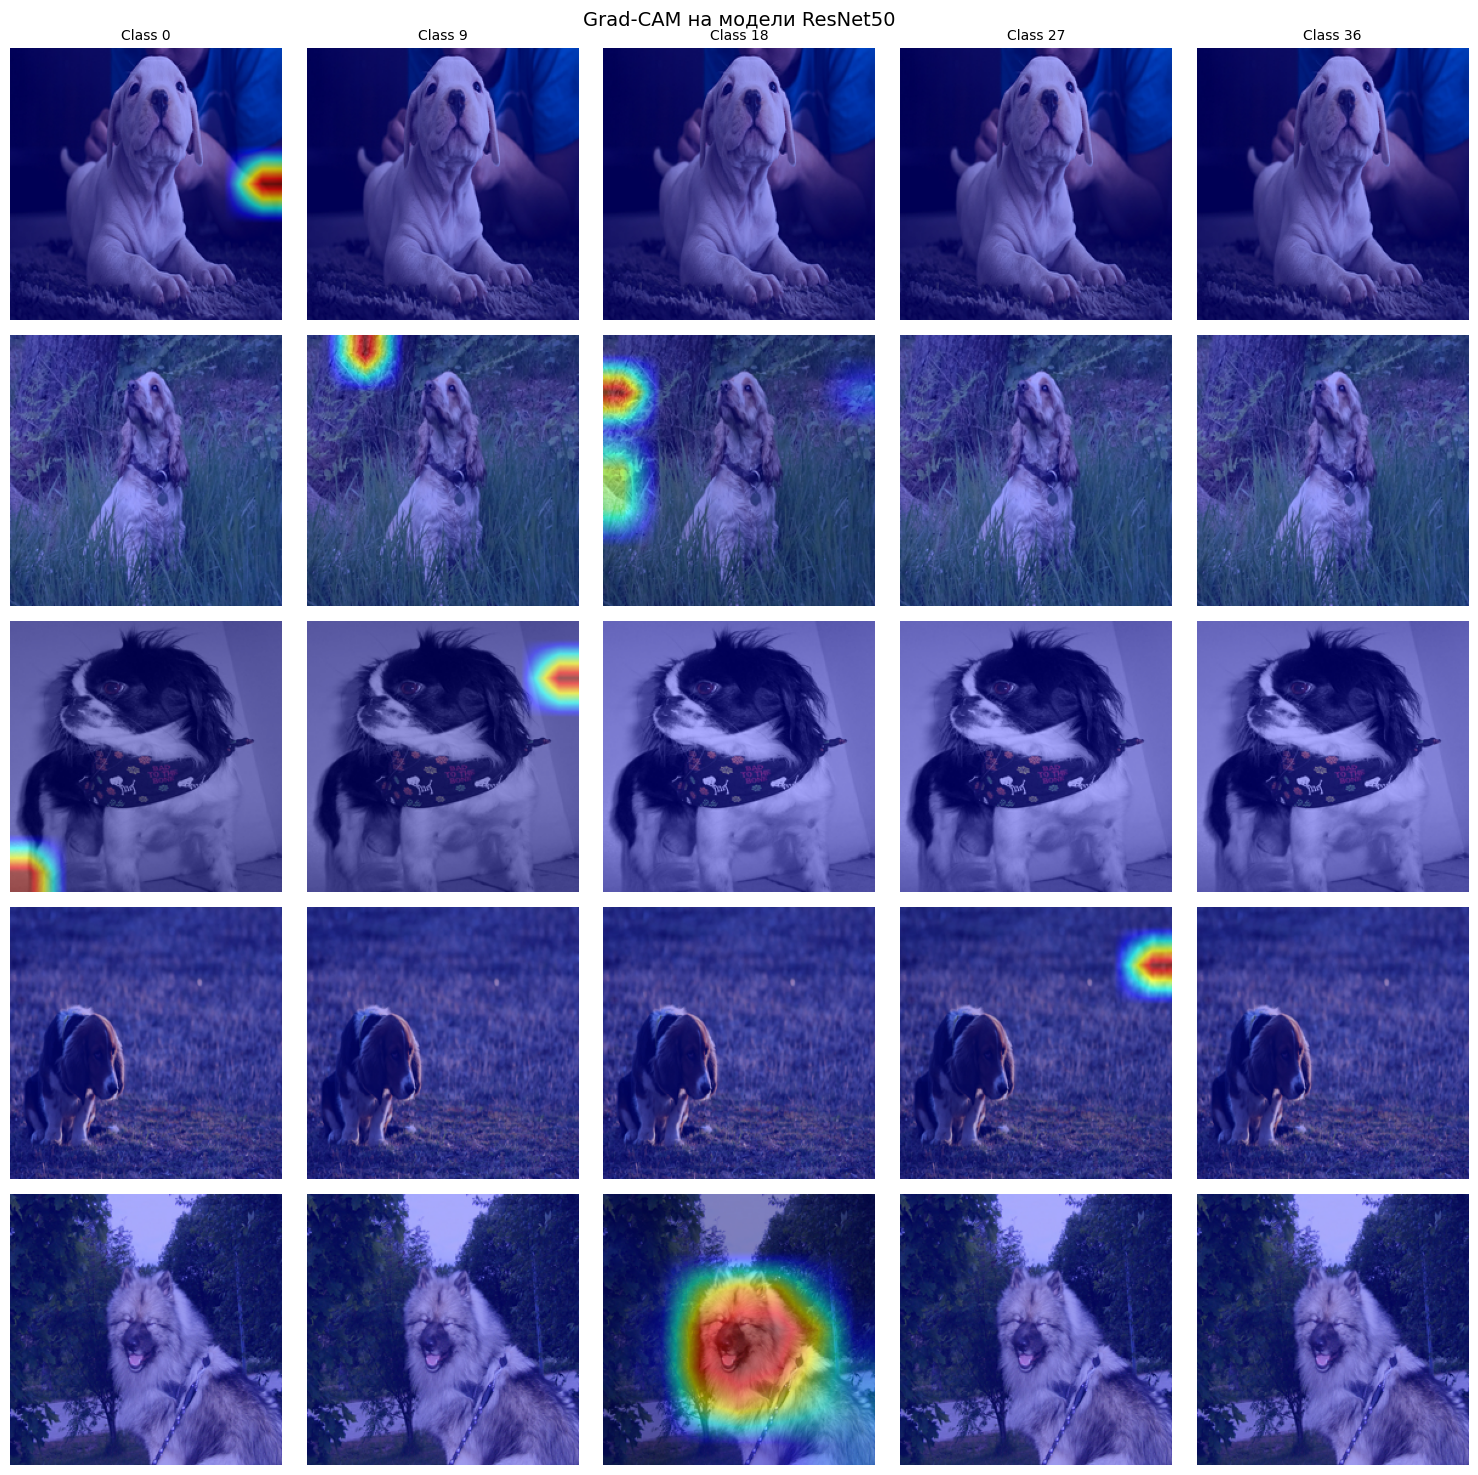

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [19]:
def get_target_layer(model):
    if hasattr(model, 'features'):
        for module in reversed(model.features):
            if isinstance(module, torch.nn.Conv2d):
                return [module]
    elif hasattr(model, 'layer4'):
        return [model.layer4[-1]]
    else:
        raise ValueError("Не удалось определить целевой слой для Grad-CAM")

original_requires_grad = {}
for name, param in best_model.named_parameters():
    original_requires_grad[name] = param.requires_grad
    param.requires_grad = True

best_model.train()

target_layers = get_target_layer(best_model)
print(f"Целевой слой: {target_layers[0]}")

cam = GradCAM(model=best_model, target_layers=target_layers)

image_indices = [0, 100, 200, 300, 400]
target_classes = [0, 9, 18, 27, 36]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

rows, cols = len(image_indices), len(target_classes)
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

for i, idx in enumerate(image_indices):
    img_tensor, true_label = val_ds[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    for j, target_class in enumerate(target_classes):
        targets = [ClassifierOutputTarget(target_class)]
        best_model.zero_grad()
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]
        vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        axes[i, j].imshow(vis)
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f"Class {target_class}", fontsize=10)
        if j == 0:
            axes[i, j].set_ylabel(f"Img {idx}\nTrue:{true_label}", fontsize=9)

plt.suptitle(f"Grad-CAM на модели {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

for name, param in best_model.named_parameters():
    param.requires_grad = original_requires_grad[name]
best_model.eval()

###Итоговые результаты

In [20]:
best_model_name = max(results, key=lambda x: results[x]['val_acc'])
best_model_acc = results[best_model_name]['val_acc']

# 1. Точность классификации пород
breed_acc = best_model_acc

# 2. Бинарная точность
best_model = results[best_model_name]['model']
best_model.eval()
binary_labels_val = [0 if lbl < 25 else 1 for lbl in y_val]
binary_preds = []
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)
        binary_preds.extend([0 if p.item() < 25 else 1 for p in preds])
species_acc = accuracy_score(binary_labels_val, binary_preds)

# 3. Top-3 и Top-5 accuracy
all_probs = []
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
all_probs = np.array(all_probs)
y_true = [0 if l < 25 else 1 for l in y_val]
y_true_breed = y_val
top3_acc = top_k_accuracy_score(y_true_breed, all_probs, k=3)
top5_acc = top_k_accuracy_score(y_true_breed, all_probs, k=5)

# Вывод
print("="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Best model: {best_model_name}")
print(f"Breed classification accuracy: {breed_acc:.4f} ({breed_acc*100:.2f}%)")
print(f"Binary classification accuracy (cat/dog): {species_acc:.4f} ({species_acc*100:.2f}%)")
print(f"Top-3 accuracy: {top3_acc:.4f} ({top3_acc*100:.2f}%)")
print(f"Top-5 accuracy: {top5_acc:.4f} ({top5_acc*100:.2f}%)")
print("="*50)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


RESULTS SUMMARY
Best model: ResNet50
Breed classification accuracy: 0.9130 (91.30%)
Binary classification accuracy (cat/dog): 0.9633 (96.33%)
Top-3 accuracy: 0.9823 (98.23%)
Top-5 accuracy: 0.9946 (99.46%)
